In [2]:
import numpy as np
import torch
from scipy.special import softmax
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import pandas as pd

In [62]:
class DualOptimizer():
    def __init__(self,
                 safety_scores,
                 reward,
                 thresholds, # E_{pi}[safety] >= thresholds
                 kl_coeff,
                 weight_decay = 0.0,
                 **kwargs):
        if reward is None:
            self.helpfulness_scores = np.zeros((safety_scores.shape[0], 1))
        else:
            self.helpfulness_scores = reward
        # Keep only samples with responses (dim1) with scores below and above threshold
        both = ((safety_scores.max(axis=(1,2))>thresholds)*(safety_scores.min(axis=(1,2))<thresholds))
        self.safety_scores = safety_scores[both]
        self.helpfulness_scores = self.helpfulness_scores[both]
        self.thresholds = thresholds
        self.kl_coeff = kl_coeff
        self.kwargs = kwargs
        self.weight_decay = weight_decay
    
    def log_mean_Z_values_old(self, logits):
        return np.log(np.mean(np.exp(logits-logits.max(axis=-1)), axis=1))+logits.max(axis=-1)
    def log_mean_Z_values(self, logits):
        # Get max along last dimension for each batch and response
        # logits shape: (2000,10)
        max_logits = logits.max(axis=-1, keepdims=True)  # Shape: (2000,1)
        
        # Subtract max and exp (stable computation)
        exp_logits = np.exp(logits - max_logits)  # Shape: (2000,10)
        
        # Mean along last two dimensions (over the 10 responses)
        mean_exp = np.mean(exp_logits, axis=-1)  # Shape: (2000)
        
        # Log and add back the max values
        return np.log(mean_exp) + max_logits.squeeze(-1)  # Shape: (2000)
    
    def solve(self, optimizer='GD', set_optimum=False, beta=0, verbose=False, **kwargs):
        lam_init = 1 if 'lam_init' not in kwargs.keys() else kwargs['lam_init']
        lr = 1 if 'lr' not in kwargs.keys() else 2*kwargs['lr']
        max_iters = 200 if 'num_iters' not in kwargs.keys() else kwargs['num_iters']
        err = 1e-3 if 'err' not in kwargs.keys() else kwargs['err']
        if optimizer == 'scipy':
            raise NotImplementedError

        if optimizer == 'GD':
            is_converge = False
            num_loops = 0
            momentum = 0
            lam = lam_init*np.ones(self.safety_scores.shape[-1])
            lam_trajectory = []
            objective_trajectory = []
            constraint_trajectory = []
            helpfulness_trajectory = []
            safety_trajectory = []
            while not is_converge:
                lr = lr/(2**(num_loops)) # learning rate decay
                for idx_iter in range(max_iters):
                    logits = (self.helpfulness_scores + ((self.safety_scores - self.thresholds) * lam).sum(axis=-1)) / self.kl_coeff
                    #print(logits)
                    sm_probs = softmax(logits, axis=-1)
                    gradient = np.sum((sm_probs)[:, :, None] * (self.safety_scores - self.thresholds), axis=1).mean(axis=0) + self.weight_decay * lam
                    #print(gradient)
                    # Nesterov momentum update
                    momentum = beta * momentum + lr * gradient
                    lam = np.maximum(lam + momentum, 0)
                    lam_trajectory.append(lam)
                    objective_trajectory.append(self.kl_coeff*np.mean(self.log_mean_Z_values(logits))-(lam*gradient).sum())
                    constraint_trajectory.append(gradient)
                    helpfulness_trajectory.append(np.sum(sm_probs * self.helpfulness_scores, axis=1).mean())
                    safety_trajectory.append(np.mean(sm_probs[:, :, None] * self.safety_scores, axis=(0, 1)))
                    if idx_iter >= 3 and np.abs(lam-np.array(lam_trajectory[-1:-3:-1])).max()<err: # the maximal difference, compared to the last 2 iterations, are smaller than 1e-5
                        is_converge = True
                        if verbose:
                            print(f'The optimization converges to a finite maximizer!')
                        break
                if is_converge:
                    print("Converged!")
                    if set_optimum:
                        self.lam_star = lam
                    break
                else:
                    print("Current Lambda")
                    print(lam)
                    print(f"Didn't converge in loop {num_loops+1}")
                num_loops += 1
                if num_loops >= 10: 
                    print(f'The dual problem (threshold={self.thresholds}, sample_shape={self.helpfulness_scores.shape}) may not have a finite maximizer!')
                    if set_optimum:
                        self.lam_star = None
                    break
            return lam_trajectory, objective_trajectory, constraint_trajectory, helpfulness_trajectory, safety_trajectory if is_converge else [None] * 5

In [31]:
multiclass_probs = torch.load("/home/chiche/pd-alignment/cache/sampled_costs_100.pt")
costs = multiclass_probs[:,:,:-1].double().cpu().numpy()
reward = None#multiclass_probs[:,:,-1].double().cpu().numpy()

In [32]:
multiclass_probs.shape

torch.Size([12000, 10, 4])

In [33]:
safe = multiclass_probs[:,:,-1].double().cpu().numpy()

In [34]:
both = ((safe.max(axis=1)>0.5)*(safe.min(axis=1)<0.5))

In [35]:
both

array([False, False,  True, ..., False,  True, False])

In [36]:
data_path 
all_data = []
with open(data_path, 'r') as f:
    for line in f:
        if line.strip():
            all_data.append(json.loads(line))

# Random sampling if n_samples is specified
if n_samples is not None and n_samples < len(all_data):
    selected_data = random.sample(all_data, n_samples)
    print(f"Randomly sampled {n_samples} prompts from {len(all_data)} total")
else:
    selected_data = all_data
    print(f"Using all {len(all_data)} prompts")

# Process selected data
all_prompts = []
all_responses = []
for data in selected_data:
    all_prompts.append(data["prompt"])
    all_responses.append(data["generated_texts"])

NameError: name 'data_path' is not defined

In [37]:
def compute_preference_datset(multiclass_probs, dataset_list):

SyntaxError: incomplete input (3310435544.py, line 1)

In [53]:
costs.shape

(12000, 10, 3)

In [59]:
thresholds = 0.5
both = ((costs.max(axis=(1,2))>thresholds)*(costs.min(axis=(1,2))<thresholds))

In [60]:
both.shape

(12000,)

In [61]:
both.sum()

np.int64(9703)

In [50]:
costs[both].mean(axis=(0, 1))


array([0.21378083, 0.25467541, 0.27601743])

In [39]:
costs[~both].mean(axis=(0, 1))

array([0.14568235, 0.27344111, 0.27319256])

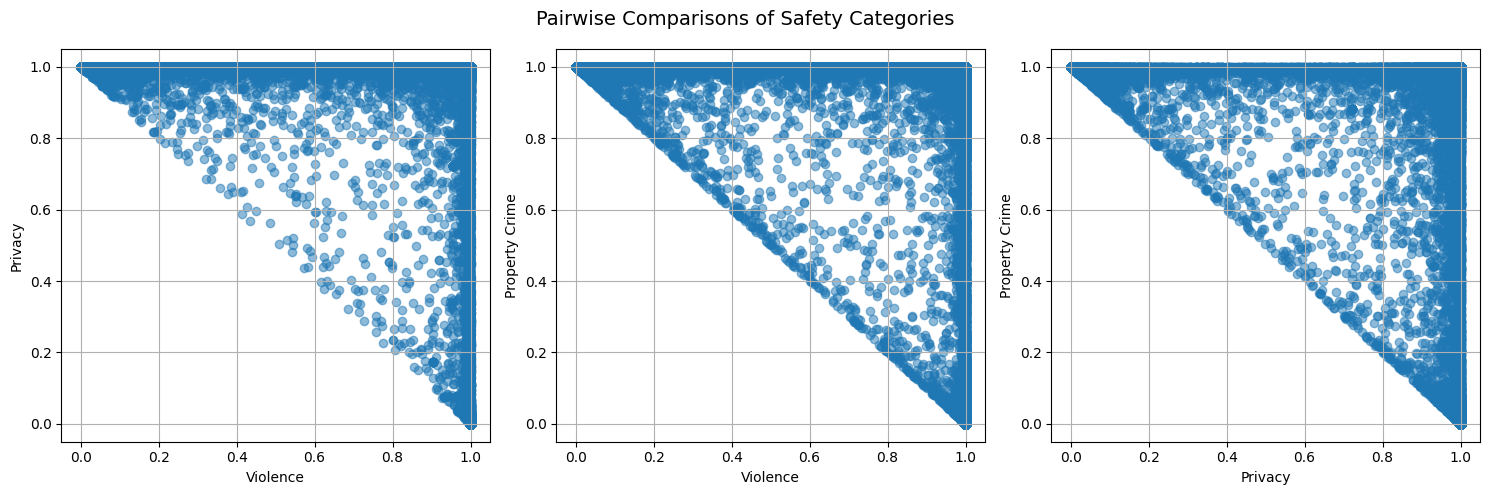

In [40]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (one for each pair)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Pairwise Comparisons of Safety Categories', fontsize=14)

# Plot each pair
categories = ['Violence', 'Privacy', 'Property Crime']
pairs = [(0,1), (0,2), (1,2)]  # Indices for pairs of categories

for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(1-costs[:, :, i].flatten(), 1-costs[:, :, j].flatten(), alpha=0.5)
    axes[idx].set_xlabel(categories[i])
    axes[idx].set_ylabel(categories[j])
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

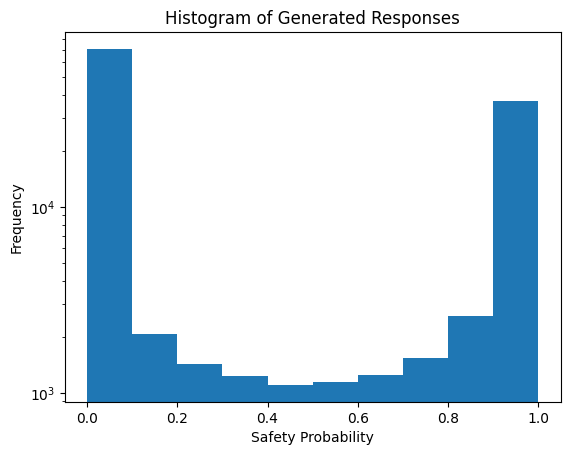

In [41]:
# print the histogram of rewards
plt.hist(multiclass_probs[:,:,-1].double().cpu().numpy().flatten())
# y axis logarithmic
plt.yscale('log')
plt.xlabel('Safety Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Generated Responses')
plt.show()


In [63]:
import numpy as np

means = np.mean(costs, axis=(0,1))
categories = ['Violence', 'Property Crime', 'Theft']

for category, mean_value in zip(categories, means):
    print(f"Mean {category}: {mean_value}")

Mean Violence: 0.18325822075599169
Mean Property Crime: 0.21811709326831144
Mean Theft: 0.2364748977144298


In [68]:
do = DualOptimizer(costs, reward, thresholds=0.1, kl_coeff=0.1, weight_decay=0.0)
lam_trajectory, objective_trajectory, constraint_trajectory, helpfulness_trajectory, safety_trajectory = do.solve(lr=1.0, max_iters=10000, beta=0.0, err=1e-5)

[0.21217564 0.1862299  0.23725072]
[0.21341506 0.185147   0.24155409]
[0.21349086 0.18370071 0.24502275]
[0.2130473  0.18226923 0.24807978]
[0.21234676 0.18113841 0.25063361]
[0.21159603 0.18033576 0.2526514 ]
[0.21094965 0.1797641  0.25418023]
[0.21046461 0.17933553 0.25530868]
[0.21012085 0.17899642 0.25614443]
[0.20987623 0.17871952 0.25677807]
[0.20969697 0.17849011 0.25727165]
[0.20956207 0.17829824 0.25766474]
[0.20945916 0.1781364  0.25798275]
[0.2093802  0.17799866 0.25824325]
[0.20931915 0.17788011 0.25845948]
[0.20927117 0.17777676 0.25864179]
[0.20923245 0.17768557 0.2587981 ]
[0.20920019 0.17760436 0.25893424]
[0.20917248 0.17753159 0.25905433]
[0.20914812 0.17746618 0.25916126]
[0.2091264  0.17740728 0.25925705]
[0.20910688 0.17735424 0.2593432 ]
[0.20908931 0.17730646 0.25942087]
[0.20907344 0.17726341 0.25949107]
[0.20905908 0.1772246  0.25955467]
[0.20904601 0.17718955 0.25961247]
[0.20903403 0.17715785 0.25966521]
[0.20902295 0.17712908 0.25971352]
[0.20901263 0.177102

KeyboardInterrupt: 

In [67]:
lam_trajectory[-1]

array([1372.93771548, 1158.63412482, 1713.4751958 ])

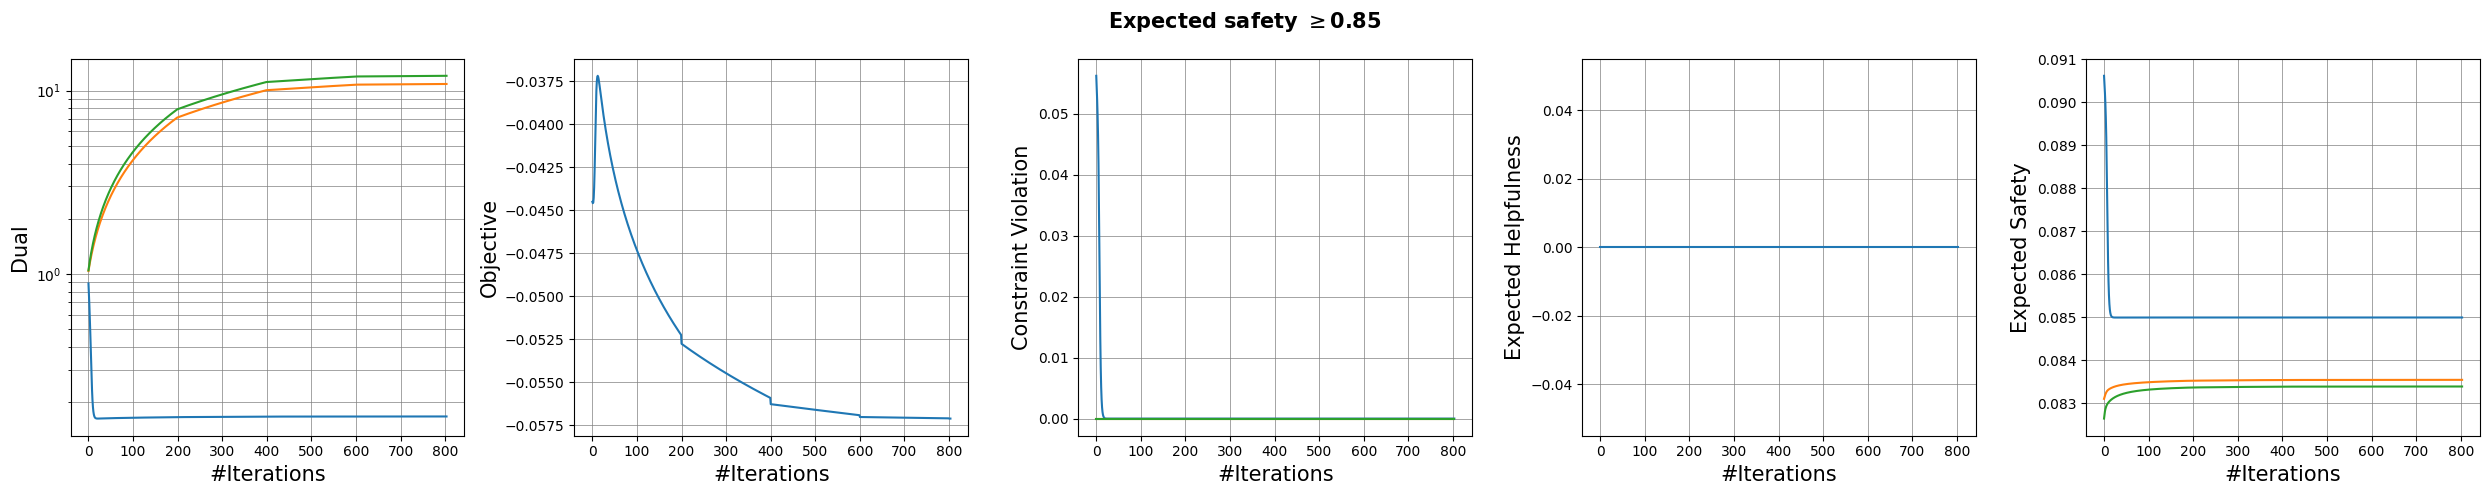

In [32]:
fig, axs = plt.subplots(1, 5, figsize=(25, 5))  # Adjust the size as needed
axs = axs.flatten()

axs[0].semilogy(lam_trajectory)
axs[0].set_ylabel('Dual', fontsize = 15)

axs[1].plot(objective_trajectory)
axs[1].set_ylabel('Objective', fontsize=15)

axs[2].plot(np.maximum(constraint_trajectory, 0))
axs[2].set_ylabel('Constraint Violation', fontsize=15)

axs[3].plot(helpfulness_trajectory)
axs[3].set_ylabel('Expected Helpfulness', fontsize=15)

axs[4].plot(safety_trajectory)
axs[4].set_ylabel('Expected Safety', fontsize=15)

for i in range(5):
    axs[i].set_xlabel('#Iterations', fontsize=15)
    axs[i].grid(True)
    axs[i].grid(which='both', color='gray', linestyle='-', linewidth=0.5)

fig.suptitle(f'Expected safety $\geq${do.thresholds}', fontsize=15, fontweight='bold')

plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.show()

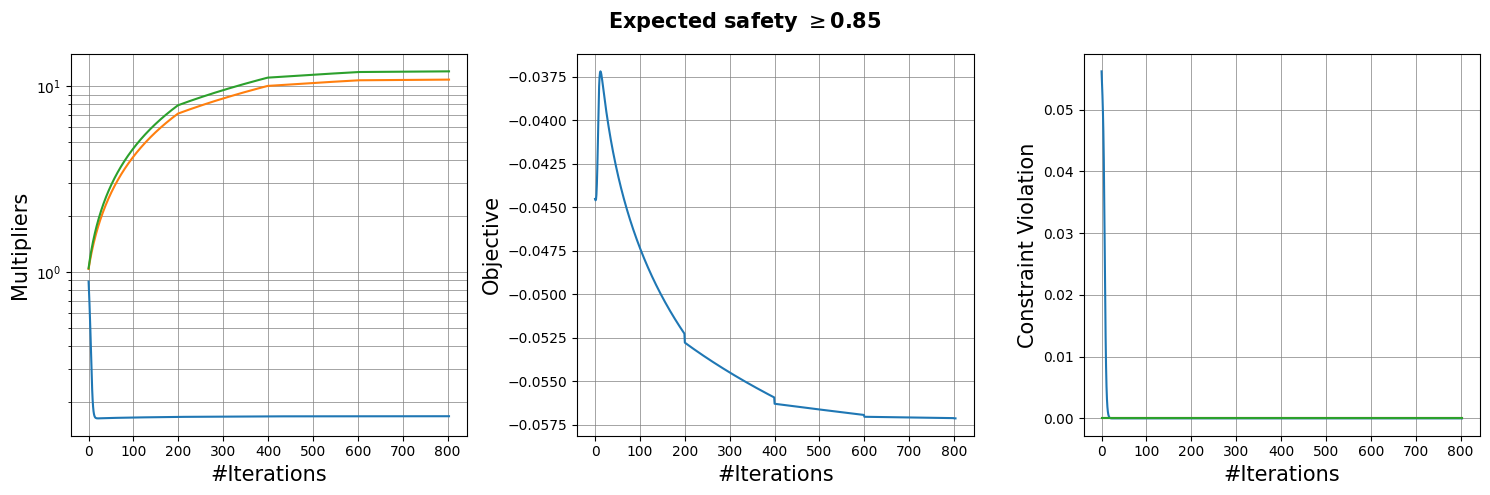

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Adjust the size as needed
axs = axs.flatten()

axs[0].semilogy(lam_trajectory)
axs[0].set_ylabel('Multipliers', fontsize = 15)

axs[1].plot(objective_trajectory)
axs[1].set_ylabel('Objective', fontsize=15)

axs[2].plot(np.maximum(constraint_trajectory, 0))
axs[2].set_ylabel('Constraint Violation', fontsize=15)


for i in range(3):
    axs[i].set_xlabel('#Iterations', fontsize=15)
    axs[i].grid(True)
    axs[i].grid(which='both', color='gray', linestyle='-', linewidth=0.5)

fig.suptitle(f'Expected safety $\geq${do.thresholds}', fontsize=15, fontweight='bold')

plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.show()

In [34]:
print("optimal multipliers:")
print(lam_trajectory[-1])

optimal multipliers:
[ 0.16716985 10.86468863 12.03735923]


## 2. Dual lanscape with respect to the (threshold, #prompts)

In [35]:
threshold_grid = np.linspace(0.8, 0.99, 5)
num_prompt_grid = list(np.linspace(100, 1401, 5).astype(np.int16))

lam_tp_list = np.full((len(threshold_grid), len(num_prompt_grid)), None, dtype=object)
for idx_lb, threshold in enumerate(threshold_grid):
    for idx_num, num_prompt in enumerate(num_prompt_grid):
        do = DualOptimizer(reward[:num_prompt], costs[:num_prompt], thresholds=threshold, kl_coeff=0.1)
        do.solve(lr=2, max_iters=200, set_optimum=True, errr=1-5, beta=0.1)
        lam_tp_list[idx_lb][idx_num] = do.lam_star

TypeError: 'NoneType' object is not subscriptable

/tmp/ipykernel_3309910/690481185.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15)


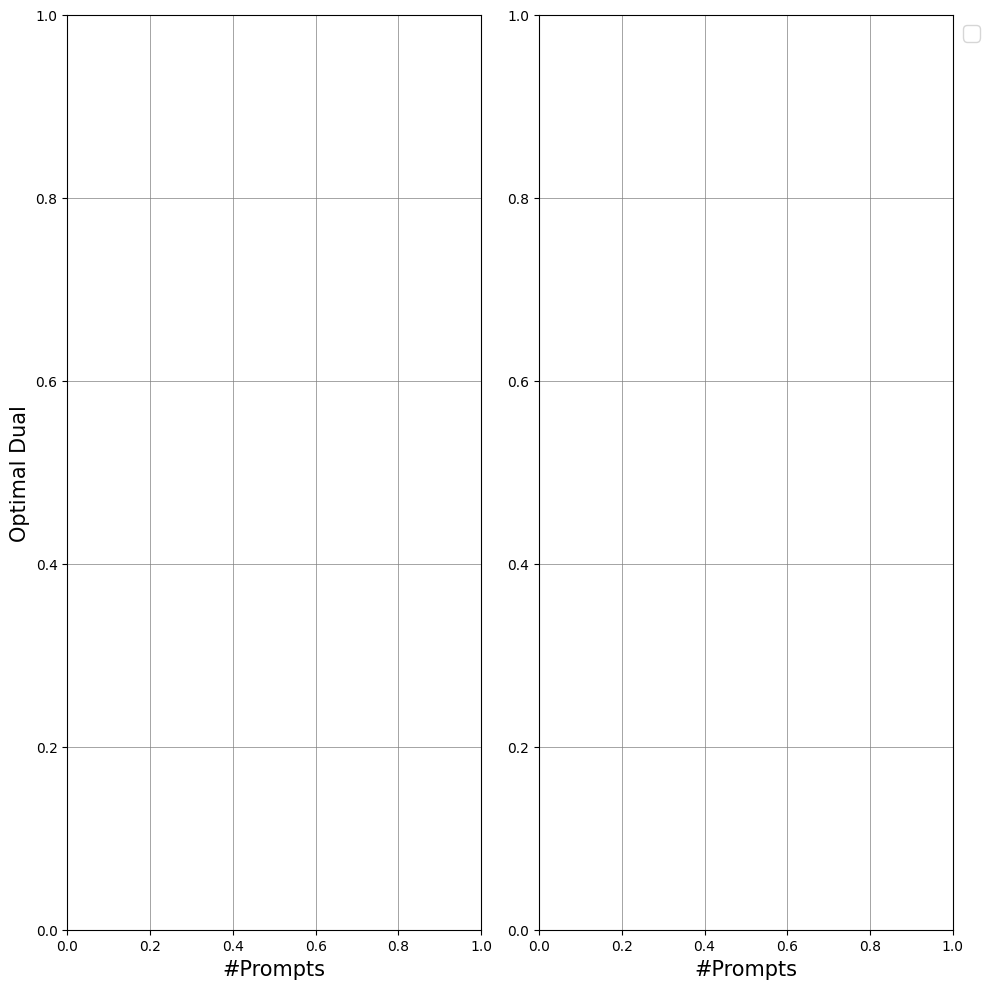

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size as needed
axs = axs.flatten()

cmap = plt.get_cmap('tab20b')
colors = [cmap(i) for i in range(20)]
for idx_lb, threshold in enumerate(threshold_grid):
    if not np.all(lam_tp_list[idx_lb]==None):
        modified_lam_tp_list = [lam for lam in lam_tp_list[idx_lb]]
        for idx_lam, lam in enumerate(modified_lam_tp_list):
            if lam != None:
                modified_lam_tp_list[idx_lam] = np.maximum(lam, 1e-8)
        axs[0].semilogy(num_prompt_grid, modified_lam_tp_list, label=f'$\\bar b$={round(threshold, 2)}', color=colors[idx_lb])
        axs[1].plot(num_prompt_grid, modified_lam_tp_list, label=f'$\\bar b$={round(threshold, 2)}', color=colors[idx_lb])

for i in range(2):
    axs[i].set_xlabel('#Prompts', fontsize=15)
    axs[i].grid(True)
    axs[i].grid(which='both', color='gray', linestyle='-', linewidth=0.5)
axs[0].set_ylabel('Optimal Dual', fontsize=15)
axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15)


plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.show()


## 3. Dual lanscape with respect to the (threshold, #responses)

In [37]:
threshold_grid = np.array([-3.0258712, -1.5194854,  -0.4047164, 1.21736907, 1.862014770, 2.63174, 2.932037353, 3.785752296447])
num_response_grid = np.arange(48, 193, 8)

lam_tc_list = np.full((len(threshold_grid), len(num_response_grid)), None, dtype=object)
for idx_lb, threshold in enumerate(threshold_grid):
    for idx_num, num_response in enumerate(num_response_grid):
        do = DualOptimizer(full_helpfulness_scores[:,:num_response], full_safety_scores[:,:num_response], thresholds=threshold, kl_coeff=0.1, err=1e-6)
        do.solve(lr=1, max_iters=200, set_optimum=True) # for PGD
        # do.solve(optimizer='scipy', lr=1, max_iters=200, set_optimum=True)
        lam_tc_list[idx_lb][idx_num] = do.lam_star

NameError: name 'full_helpfulness_scores' is not defined

/tmp/ipykernel_3309910/3379889300.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15)


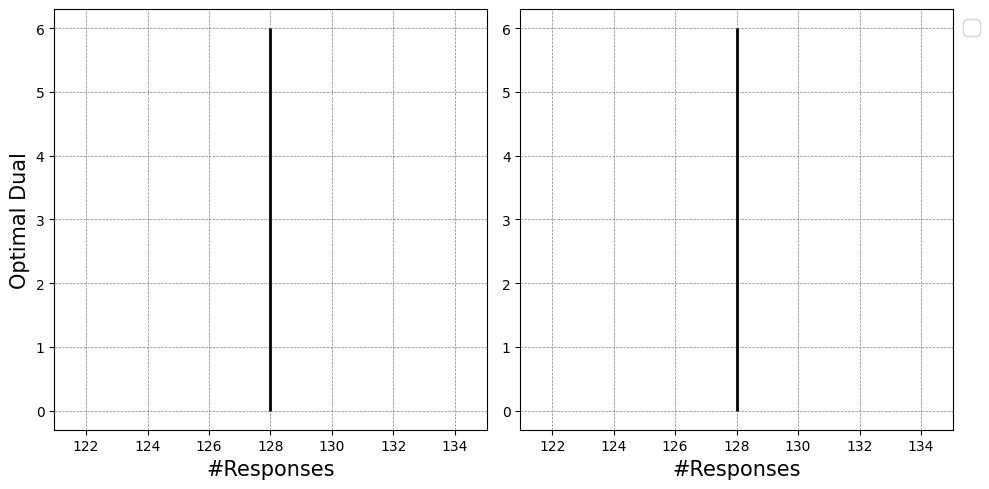

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Adjust the size as needed
axs = axs.flatten()

cmap = plt.get_cmap('tab20b')
colors = [cmap(i) for i in range(20)]
for idx_lb, threshold in enumerate(threshold_grid):
    if not np.all(lam_tc_list[idx_lb]==None):
        modified_lam_tc_list = [lam for lam in lam_tc_list[idx_lb]]
        for idx_lam, lam in enumerate(modified_lam_tc_list):
            if lam != None:
                modified_lam_tc_list[idx_lam] = np.maximum(lam, 1e-8)
        axs[0].semilogy(num_response_grid, modified_lam_tc_list, label=f'$\\bar b$={round(threshold, 2)}', color=colors[idx_lb])
        axs[1].plot(num_response_grid, modified_lam_tc_list, label=f'$\\bar b$={round(threshold, 2)}', color=colors[idx_lb])

for i in range(2):
    axs[i].vlines(128, linewidth=2, colors = 'black', ymin=0, ymax=6)
    axs[i].set_xlabel('#Responses', fontsize=15)
    axs[i].grid(True)
    axs[i].grid(which='both', color='gray', linestyle='--', linewidth=0.5)
axs[0].set_ylabel('Optimal Dual', fontsize=15)
axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15)


plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.show()

## 4. Find the predicted threshold for target $\lambda$

In [39]:
import pdb

class Predictor():
    def __init__(self,
                 helpfulness_scores,
                 safety_scores,
                 **kwargs):
        self.helpfulness_scores = helpfulness_scores
        self.safety_scores = safety_scores
        self.kwargs = kwargs
    
    def predict(self, lam_grid, kl_coeff, threshold_low = -3, threshold_high=3, **kwargs):
        err = 1e-5 if 'err' not in kwargs.keys() else kwargs['err']
        optimizer = 'GD' if 'optimizer' not in kwargs.keys() else kwargs['optimizer']
        def threshold2lam(threshold, err):
            do = DualOptimizer(self.helpfulness_scores, self.safety_scores, thresholds=threshold, kl_coeff=kl_coeff)
            if optimizer != 'scipy':
                am_trajectory, objective_trajectory, constraint_trajectory, helpfulness_trajectory, safety_trajectory = do.solve(optimizer = optimizer, lr=1, max_iters=200, set_optimum=True, err= err)
                return do.lam_star, helpfulness_trajectory[-1]
            else:
                do.solve(optimizer = optimizer, lr=1, max_iters=200, set_optimum=True, err= err)
                return do.lam_star, 0
        lam_low, help_low = threshold2lam(threshold_low, err)
        lam_high, help_high = threshold2lam(threshold_high, err)
        lam2threshold_map = {lam_low: (threshold_low, help_low), lam_high: (threshold_high, help_high)}
        if lam_low == None:
            print(f'The lower threshold bound {threshold_low} is too high!')
            return
        if lam_high == None:
            print(f'The upper threshold bound {threshold_high} is too high!')
            return
        res = {}
        for lam in lam_grid:
            while True:
                lam_list = np.sort(np.array(list(lam2threshold_map.keys())))
                # pdb.set_trace()
                if lam < lam_list[0]-err:
                    print(f'The lower threshold bound is too high to cover lambda={lam}!')
                    break
                elif lam > lam_list[-1] +err:
                    print(f'The upper threshold bound is too low to cover lambda={lam}!')
                    break
                elif lam < lam_list[0]+err:
                    res[lam] = lam2threshold_map[lam_list[0]][0]
                    break
                elif lam > lam_list[-1]-err:
                    res[lam] = lam2threshold_map[lam_list[-1]][0]
                    break
                else:
                    lam_left, lam_right = lam_list[lam_list<lam][-1], lam_list[lam_list>lam][0]
                    if np.abs(lam_left-lam)<err: 
                        res[lam] = lam2threshold_map[lam_left][0]
                        break 
                    elif np.abs(lam_right-lam)<err: 
                        res[lam] = lam2threshold_map[lam_right][0]
                        break
                    else:
                        threshold_mid = (lam2threshold_map[lam_left][0]+lam2threshold_map[lam_right][0])/2
                        lam_tmp, help_tmp = threshold2lam(threshold_mid, err)
                        lam2threshold_map[lam_tmp] = (threshold_mid, help_tmp)

        return res

In [40]:
lam_list = [0.1, 0.3511, 0.5, 0.7547, 0.9, 1.1263, 1.25, 2, 3]
dp = Predictor(full_helpfulness_scores[idx_sample, :128], full_safety_scores[idx_sample, :128])
dp.predict(lam_list, 0.1, threshold_low = -3.5, threshold_high=4.0, errr=1-4, optimizer='scipy')

NameError: name 'full_helpfulness_scores' is not defined

In [120]:
lam_list = [0.1, 0.3511, 0.5, 0.7547, 0.9, 1.1263, 1.25, 2, 3]
dp = Predictor(full_helpfulness_scores[idx_sample, :128], full_safety_scores[idx_sample, :128])
dp.predict(lam_list, 0.1, threshold_low = -3.5, threshold_high=4.4, errr=1-6)

{0.1: -3.025898742675781,
 0.3511: -1.5194549560546873,
 0.5: -0.4047805786132811,
 0.7547: 1.2173858642578126,
 0.9: 1.862057495117188,
 1.1263: 2.63176383972168,
 1.25: 2.932040023803711,
 2: 3.785750770568848,
 3: 4.1847566127777105}

## 5. Dual loss landscape

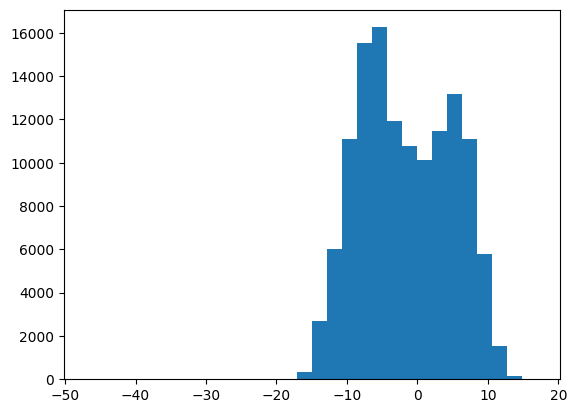

In [135]:
# plt.scatter(full_safety_scores[idx_sample, :128], full_helpfulness_scores[idx_sample, :128], s=0.1)
n, bins, patches = plt.hist(full_safety_scores[idx_sample, :128].reshape(-1), bins=30)
default_color = patches[0].get_facecolor()

ValueError: Invalid RGBA argument: np.float64(0.12156862745098039)

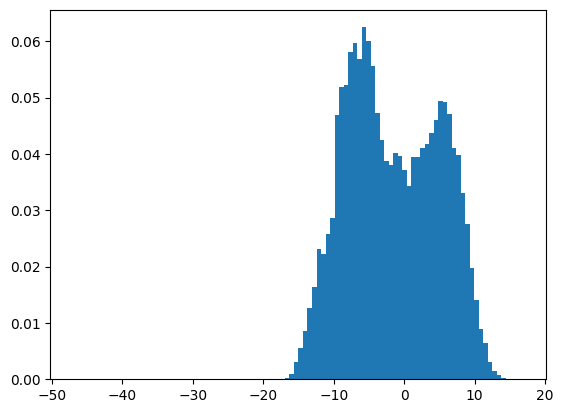

In [136]:

plt.hist(full_safety_scores[idx_sample, :128].reshape(-1), bins=100, edgecolor=default_color, color =default_color, density=True)
plt.xlabel(r'$g(x,y)$', fontsize=20)
plt.ylabel('Density', fontsize=20)
plt.xlim(-25, 25)
# plt.ylim(-25,10)
plt.subplots_adjust(bottom=0.17, left=0.17)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.savefig('dual_safety_boundedness.pdf')

In [137]:
def dual_loss(lam_grid, helpfulness_scores, safety_scores, threshold=1., kl_coeff=0.1):
    res = []
    for lam in lam_grid:
        logits = (helpfulness_scores + (safety_scores - threshold) * lam) / kl_coeff
        logits_max = logits.max(axis=1).reshape(-1, 1)
        res.append(kl_coeff*np.mean(np.log(np.mean(np.exp(logits-logits_max)))+logits_max))
    return np.array(res)

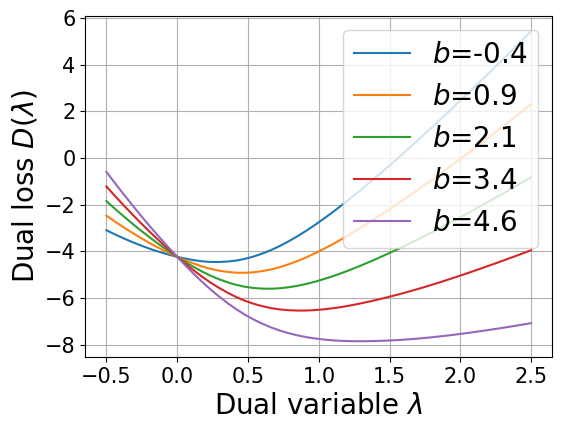

In [138]:
lam_grid = np.linspace(-0.5, 2.5, 50)
threshold_grid = np.linspace(-2, 3, 5)
threshold_SFT = full_safety_scores.mean()
for threshold in threshold_grid:
    losses = dual_loss(lam_grid, full_helpfulness_scores[idx_sample, :128], full_safety_scores[idx_sample, :128], threshold=threshold, kl_coeff=0.1)
    plt.plot(lam_grid, losses, label=rf'$b$={round(threshold-threshold_SFT,1)}')
    # plt.hlines(losses.min()-1e-2,  xmin=-0.5, xmax=2.5, linestyles='dashed', color='black')
plt.xlabel(r'Dual variable $\lambda$', fontsize =20)
plt.ylabel(r'Dual loss $D(\lambda)$', fontsize =20)
plt.subplots_adjust(bottom=0.17, left=0.17)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(fontsize=20, loc='upper right')
plt.grid()
plt.savefig('dual_loss.pdf')

-2.0 0.2701027519932559
-0.75 0.45670044832705076
0.5 0.647434382061969
1.75 0.8708815534685502
3.0 1.2901170882363215


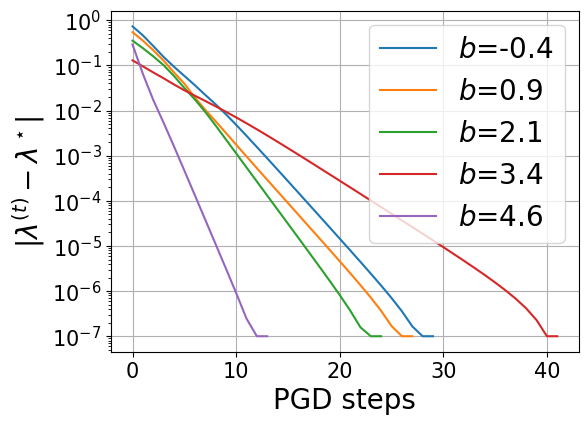

In [139]:
for threshold in threshold_grid:
    do = DualOptimizer(full_helpfulness_scores[idx_sample, :128], full_safety_scores[idx_sample, :128], thresholds=threshold, kl_coeff=0.1)
    # do.solve(optimizer='scipy', set_optimum=True)
    # lam_star = do.lam_star
    lam_trajectory, objective_trajectory, constraint_trajectory, helpfulness_trajectory, safety_trajectory = do.solve(lr=2, max_iters=1000, err=1e-7, set_optimum=True)
    print(threshold, do.lam_star)
    plt.semilogy(np.maximum(np.abs(np.array([1]+lam_trajectory)-do.lam_star), 1e-7), label=rf'$b$={round(threshold-threshold_SFT,1)}')
plt.subplots_adjust(bottom=0.17, left=0.17)
plt.ylabel(r'$|\lambda^{(t)}-\lambda^\star|$', fontsize = 20)
plt.xlabel('PGD steps', fontsize = 20)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(fontsize = 20)
plt.grid()
plt.savefig('dual_PGD.pdf')

In [ ]:
for threshold in threshold_grid:
    do = DualOptimizer(full_helpfulness_scores[idx_sample, :128], full_safety_scores[idx_sample, :128], thresholds=threshold, kl_coeff=0.1)
    # do.solve(optimizer='scipy', set_optimum=True)
    # lam_star = do.lam_star
    lam_trajectory, objective_trajectory, constraint_trajectory, helpfulness_trajectory, safety_trajectory = do.solve(lr=2, max_iters=100, err=1e-5, set_optimum=True, beta=0.00)
    print(threshold, do.lam_star)
    plt.semilogy(np.maximum(np.abs(np.array([1]+lam_trajectory)-do.lam_star), 1e-7), label=rf'$b$={round(threshold-threshold_SFT,1)}')
plt.subplots_adjust(bottom=0.17, left=0.17)
plt.ylabel(r'$|\lambda^{(t)}-\lambda^\star|$', fontsize = 20)
plt.xlabel('steps', fontsize = 20)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(fontsize = 20)
plt.grid()
plt.savefig('dual_PGD.pdf')

NameError: name 'threshold_grid' is not defined